# Step 2.2 — Radar Filtering + Feature Extraction (Upgraded) ✅

| | |
|---|---|
| **Input** | `output/step_1/radar/<sample>/<channel>.json` (from upgraded Step 1.2) |
| **Outputs** | `output/step_2/radar/<sample>/<channel>.json` — filtered points + calibration |
| | `output/step_2/radar_summary.csv` — per-sample filtering stats |
| **Used by** | Step 3.2 (radar tracking), Step 4.2/4.4 (fusion) |

---

### Critical fix — output format compatibility

The upgraded Step 1.2 changed its output structure from a plain list of points to a dict: `{"calibration": {...}, "points": [...]}` — this was necessary to carry calibration data forward for camera projection. **This notebook must unwrap `["points"]` before iterating**, or it will crash trying to iterate over the dict's keys instead of the actual points. Fixed below.

### Bonus fix that comes for free

Your `dyn_prop == 7` filter (excluding "unknown motion" points) was silently never triggering in the original pipeline, because the old Step 1.2 bug meant `dyn_prop` actually held `is_quality_valid` (0 or 1) instead of the real 0–7 motion enum. Now that Step 1.2 is fixed, this filter is functional for the first time.

### What's new

- Calibration data is carried forward into this step's output too — needed later for radar-to-camera projection and fusion.
- Both raw (`vx, vy`) and compensated (`vx_comp, vy_comp`) velocity are kept: raw for TTC/closing-speed, compensated for true motion classification.
- Named constants replace magic numbers (`100` for range cutoff).
- Summary CSV added for quick inspection of filtering effectiveness per sample.

In [1]:
# ─────────────────────────────────────────────────────────────────
# CELL 1 — Verify config.py exists
# ─────────────────────────────────────────────────────────────────

from pathlib import Path

if not Path("config.py").exists():
    raise FileNotFoundError("config.py not found. Copy it from the repo root.")

from config import STEP1_DIR, STEP2_DIR

RADAR_IN_DIR  = STEP1_DIR / "radar"
RADAR_OUT_DIR = STEP2_DIR / "radar"
RADAR_OUT_DIR.mkdir(parents=True, exist_ok=True)

if not RADAR_IN_DIR.exists():
    raise FileNotFoundError(f"Step 1.2 output not found at {RADAR_IN_DIR} — run Step 1.2 first.")

print(f"✅ RADAR_IN_DIR  : {RADAR_IN_DIR}")
print(f"✅ RADAR_OUT_DIR : {RADAR_OUT_DIR}")

config.py loaded. PROJECT_ROOT = F:\Sensor fusion Research
DATA_ROOT   = F:\Sensor fusion Research\DATA SET\archive
OUTPUT_ROOT = F:\Sensor fusion Research\output
✅ RADAR_IN_DIR  : F:\Sensor fusion Research\output\step_1\radar
✅ RADAR_OUT_DIR : F:\Sensor fusion Research\output\step_2\radar


In [2]:
# ─────────────────────────────────────────────────────
# CELL 2 — Named constants
# ─────────────────────────────────────────────────────

MAX_RANGE_M = 100.0          # discard detections beyond this range

# nuScenes dyn_prop enum (from RadarPointCloud.from_file docstring):
#   0 moving, 1 stationary, 2 oncoming, 3 stationary candidate,
#   4 unknown, 5 crossing stationary, 6 crossing moving, 7 stopped
# The devkit itself recommends dynprop_states=[0, 2, 6] for "moving objects only".
# FIXED: previously only dyn_prop == 7 ("stopped") was excluded, so stationary (1),
# stationary-candidate (3), and crossing-stationary (5) clutter passed straight through.
MOVING_DYN_PROPS = {0, 2, 6}  # moving, oncoming, crossing-moving
VELOCITY_ZERO_EPS = 1e-9     # treat |v| below this as "no motion data"

print(f"\u2705 MAX_RANGE_M = {MAX_RANGE_M}m, keep dyn_prop in {sorted(MOVING_DYN_PROPS)} (moving/oncoming/crossing-moving)")


✅ MAX_RANGE_M = 100.0m, keep dyn_prop in [0, 2, 6] (moving/oncoming/crossing-moving)


In [3]:
# ─────────────────────────────────────────────────────────────────
# CELL 3 — Main pipeline: filter + extract features
# FIXED: unwraps ["points"] from the new Step 1.2 dict structure
# FIXED: carries calibration forward for downstream projection
# ─────────────────────────────────────────────────────────────────

import json
import math
from tqdm import tqdm

sample_folders = sorted([p for p in RADAR_IN_DIR.iterdir() if p.is_dir()])
summary_rows = []

for sample_folder in tqdm(sample_folders, desc="Processing radar samples"):
    sample_id = sample_folder.name
    out_sample_folder = RADAR_OUT_DIR / sample_id
    out_sample_folder.mkdir(parents=True, exist_ok=True)

    for radar_file in sample_folder.glob("RADAR_*.json"):
        radar_channel = radar_file.stem

        with open(radar_file) as f:
            radar_data = json.load(f)

        # FIXED — unwrap the "points" list from the dict structure
        raw_points = radar_data["points"]
        calibration = radar_data.get("calibration", {})

        cleaned_points = []
        n_dropped_invalid = 0
        n_dropped_zero_velocity = 0
        n_dropped_not_moving = 0
        n_dropped_range = 0

        for pt in raw_points:
            x, y = pt["x"], pt["y"]
            vx, vy = pt.get("vx", 0.0), pt.get("vy", 0.0)               # raw — for TTC
            vx_comp, vy_comp = pt.get("vx_comp", 0.0), pt.get("vy_comp", 0.0)  # compensated — for motion classification
            dyn_prop = pt.get("dyn_prop", -1)
            is_quality_valid = pt.get("is_quality_valid", None)
            valid = pt.get("valid", False)

            range_val = math.hypot(x, y)
            azimuth = math.degrees(math.atan2(y, x))
            rel_speed = (x * vx + y * vy) / range_val if range_val > 0 else 0.0

            # ── Filters (named constants, transparent) ──
            if not valid:
                n_dropped_invalid += 1
                continue
            if abs(vx) < VELOCITY_ZERO_EPS and abs(vy) < VELOCITY_ZERO_EPS:
                n_dropped_zero_velocity += 1
                continue
            if dyn_prop not in MOVING_DYN_PROPS:
                n_dropped_not_moving += 1
                continue
            if range_val > MAX_RANGE_M:
                n_dropped_range += 1
                continue

            cleaned_points.append({
                "x": x, "y": y, "z": pt.get("z", 0.0),
                "vx": vx, "vy": vy,
                "vx_comp": vx_comp, "vy_comp": vy_comp,
                "dyn_prop": dyn_prop,
                "is_quality_valid": is_quality_valid,
                "range": round(range_val, 3),
                "azimuth": round(azimuth, 2),
                "relative_speed": round(rel_speed, 3)
            })

        out_data = {
            "sample_id": sample_id,
            "radar_channel": radar_channel,
            "calibration": calibration,   # carried forward for projection/fusion
            "points": cleaned_points
        }

        out_path = out_sample_folder / f"{radar_channel}.json"
        with open(out_path, "w") as f:
            json.dump(out_data, f, indent=2)

        summary_rows.append({
            "sample_id": sample_id,
            "radar_channel": radar_channel,
            "num_raw": len(raw_points),
            "num_kept": len(cleaned_points),
            "dropped_invalid": n_dropped_invalid,
            "dropped_zero_velocity": n_dropped_zero_velocity,
            "dropped_not_moving": n_dropped_not_moving,
            "dropped_range": n_dropped_range,
        })

assert len(summary_rows) > 0, "No radar files processed — check RADAR_IN_DIR"
print(f"\n✅ Step 2.2 complete. Cleaned radar saved to: {RADAR_OUT_DIR}")

Processing radar samples:   0%|          | 0/404 [00:00<?, ?it/s]

Processing radar samples:   5%|▌         | 21/404 [00:00<00:01, 199.93it/s]

Processing radar samples:  10%|█         | 42/404 [00:00<00:01, 200.57it/s]

Processing radar samples:  16%|█▌        | 63/404 [00:00<00:01, 198.27it/s]

Processing radar samples:  21%|██        | 83/404 [00:00<00:01, 193.98it/s]

...

Processing radar samples:  87%|████████▋ | 351/404 [00:02<00:00, 127.89it/s]

Processing radar samples:  92%|█████████▏| 372/404 [00:02<00:00, 144.05it/s]

Processing radar samples:  99%|█████████▊| 398/404 [00:03<00:00, 169.32it/s]

Processing radar samples: 100%|██████████| 404/404 [00:03<00:00, 132.56it/s]


✅ Step 2.2 complete. Cleaned radar saved to: F:\Sensor fusion Research\output\step_2\radar


In [4]:
# ─────────────────────────────────────────────────────────────────
# CELL 4 — Summary CSV + filtering effectiveness
# ─────────────────────────────────────────────────────────────────

import pandas as pd

summary_df = pd.DataFrame(summary_rows)
summary_path = STEP2_DIR / "radar_summary.csv"
summary_df.to_csv(summary_path, index=False)

total_raw = summary_df["num_raw"].sum()
total_kept = summary_df["num_kept"].sum()

print(f"✅ Summary saved: {summary_path}")
print(f"   Total raw points     : {total_raw}")
print(f"   Total kept points    : {total_kept} ({total_kept/total_raw*100:.1f}%)")
print(f"   Dropped — invalid     : {summary_df['dropped_invalid'].sum()}")
print(f"   Dropped — zero velocity: {summary_df['dropped_zero_velocity'].sum()}")
print(f"   Dropped — not moving: {summary_df['dropped_not_moving'].sum()}")
print(f"   Dropped — out of range: {summary_df['dropped_range'].sum()}")

zero_kept = summary_df[summary_df["num_kept"] == 0]
if len(zero_kept) > 0:
    print(f"\n⚠️ {len(zero_kept)} sample/channel combos kept ZERO points after filtering.")

display(summary_df.head())

✅ Summary saved: F:\Sensor fusion Research\output\step_2\radar_summary.csv
   Total raw points     : 79519
   Total kept points    : 11111 (14.0%)
   Dropped — invalid     : 0
   Dropped — zero velocity: 12511
   Dropped — not moving: 55542
   Dropped — out of range: 355



⚠️ 491 sample/channel combos kept ZERO points after filtering.


,sample_id,radar_channel,num_raw,num_kept,dropped_invalid,dropped_zero_velocity,dropped_not_moving,dropped_range
0,sample_0000,RADAR_BACK_LEFT,61,3,0,0,58,0
1,sample_0000,RADAR_BACK_RIGHT,57,4,0,0,53,0
2,sample_0000,RADAR_FRONT,74,9,0,0,65,0
3,sample_0000,RADAR_FRONT_LEFT,22,13,0,0,9,0
4,sample_0000,RADAR_FRONT_RIGHT,27,19,0,0,8,0


## Visualize cleaned radar detections with velocity arrows

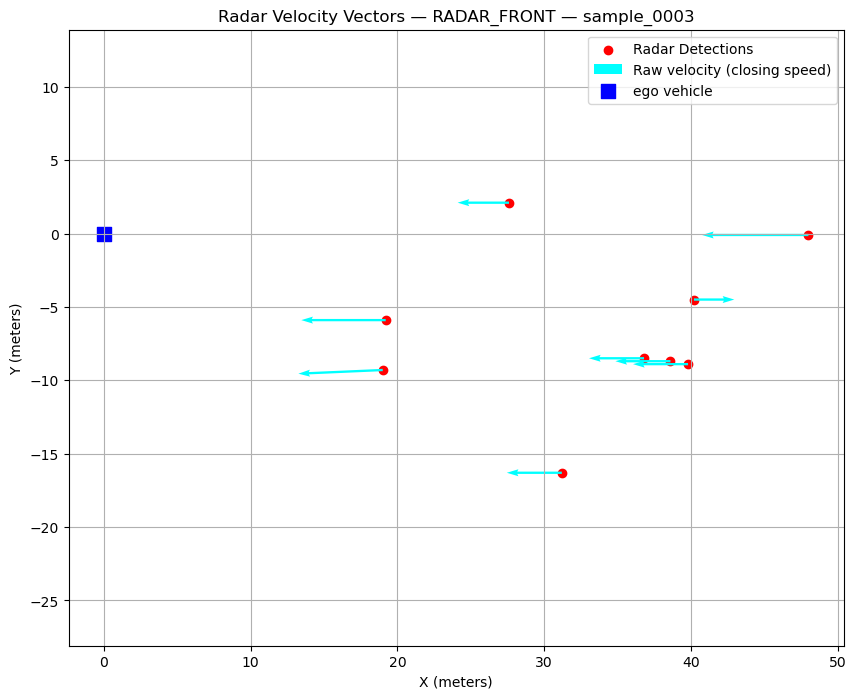

📄 Saved: F:\Sensor fusion Research\output\step_2\radar_viz_sample_0003_RADAR_FRONT.png


In [5]:
# ─────────────────────────────────────────────────────────────────
# CELL 5 — Visualize radar points + velocity vectors for one sample
# FIXED: unwraps ["points"], uses config paths
# ─────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt

sample_id = "sample_0003"       # ← change to inspect any sample
radar_channel = "RADAR_FRONT"

radar_path = RADAR_OUT_DIR / sample_id / f"{radar_channel}.json"
with open(radar_path) as f:
    radar_data = json.load(f)

radar_pts = radar_data["points"]   # FIXED — unwrap dict structure

if len(radar_pts) == 0:
    print(f"No valid radar points found in {radar_path}")
else:
    xy = np.array([[pt["x"], pt["y"]] for pt in radar_pts])
    vxy = np.array([[pt["vx"], pt["vy"]] for pt in radar_pts])  # raw velocity — closing speed

    plt.figure(figsize=(10, 8))
    plt.scatter(xy[:, 0], xy[:, 1], c='red', label='Radar Detections')
    plt.quiver(xy[:, 0], xy[:, 1], vxy[:, 0], vxy[:, 1],
               angles='xy', scale_units='xy', scale=1, color='cyan', width=0.003,
               label='Raw velocity (closing speed)')
    plt.scatter(0, 0, c='blue', s=100, marker='s', label='ego vehicle')

    plt.title(f"Radar Velocity Vectors — {radar_channel} — {sample_id}")
    plt.xlabel('X (meters)'); plt.ylabel('Y (meters)')
    plt.axis('equal'); plt.grid(True); plt.legend()

    save_path = STEP2_DIR / f"radar_viz_{sample_id}_{radar_channel}.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"📄 Saved: {save_path}")

🟥 Red dots = radar detections after filtering

🔵 Cyan arrows = raw (relative) velocity vectors — the correct field for closing-speed / TTC

---

## ✅ Ready for Step 3: Temporal Data Association

This step's output now includes:
- Clean `x, y, vx, vy` (raw) and `vx_comp, vy_comp` (compensated)
- `calibration` carried forward — needed to transform into ego/global frame and project onto cameras
- Correct `dyn_prop` filtering (fixed upstream in Step 1.2)

This feeds directly into Step 3.2 (radar tracking) and Step 4.2/4.4 (fusion).